In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(base_dir, "data")

clean_file = os.path.join(data_dir, "epl_team_matches_clean.csv")
df = pd.read_csv(clean_file, parse_dates=["Date"])

print("Team-match shape:", df.shape)
df.head()


Team-match shape: (1520, 18)


,Date,team,opponent,goals_for,goals_against,shots_for,shots_against,sot_for,sot_against,corners_for,corners_against,total_goals,over25,is_home,goal_diff,is_win,is_draw,is_loss
0,2022-08-05,Arsenal,Crystal Palace,2,0,10,10,2,2,5,3,2,0,0,2,1,0,0
1,2022-08-13,Arsenal,Leicester,4,2,19,6,7,2,6,2,6,1,1,2,1,0,0
2,2022-08-20,Arsenal,Bournemouth,3,0,14,6,6,1,4,3,3,1,0,3,1,0,0
3,2022-08-27,Arsenal,Fulham,2,1,22,11,8,3,9,2,3,1,1,1,1,0,0
4,2022-08-31,Arsenal,Aston Villa,2,1,22,4,9,3,10,3,3,1,1,1,1,0,0


In [2]:
# Summary of numeric columns
df.describe()


,Date,goals_for,goals_against,shots_for,shots_against,sot_for,sot_against,corners_for,corners_against,total_goals,over25,is_home,goal_diff,is_win,is_draw,is_loss
count,1520,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000,1520.000000
mean,2023-07-08 18:37:53.684210432,1.532895,1.532895,13.211842,13.211842,4.667763,4.667763,5.236184,5.236184,3.065789,0.586842,0.500000,0.000000,0.388816,0.222368,0.388816
min,2022-08-05 00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.000000,0.000000,0.000000,0.000000
25%,2023-01-21 00:00:00,1.000000,1.000000,9.000000,9.000000,3.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
50%,2023-07-04 12:00:00,1.000000,1.000000,13.000000,13.000000,4.000000,4.000000,5.000000,5.000000,3.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000
75%,2023-12-30 00:00:00,2.000000,2.000000,17.000000,17.000000,6.000000,6.000000,7.000000,7.000000,4.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,2024-05-19 00:00:00,9.000000,9.000000,36.000000,36.000000,15.000000,15.000000,19.000000,19.000000,9.000000,1.000000,1.000000,9.000000,1.000000,1.000000,1.000000
std,NaN,1.330840,1.330840,5.803326,5.803326,2.605916,2.605916,3.080039,3.080039,1.736686,0.492563,0.500165,2.017044,0.487642,0.415974,0.487642


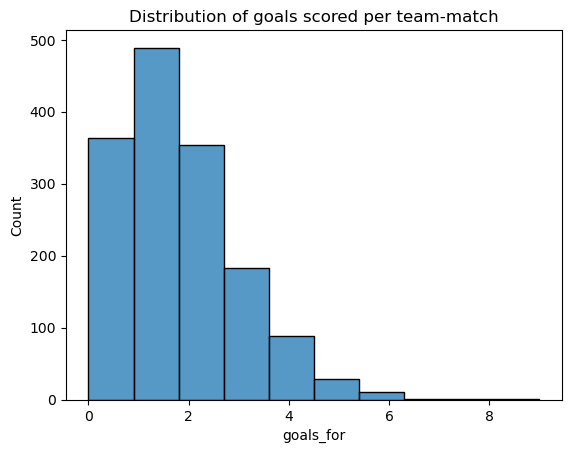

In [3]:
# Distribution of goals_for
sns.histplot(df["goals_for"], bins=10, kde=False)
plt.title("Distribution of goals scored per team-match")
plt.show()


## If the bar above 1 on the x‑axis has height 450, that means 450 rows in your dataset where goals_for = 1 (a team scored exactly 1 goal in that match).
## If the bar above 0 is 350, that means 350 team‑matches where the team scored 0 goals, and so on.

# Result and over/under frequencies

In [4]:
# Share of wins/draws/losses
result_counts = df[["is_win", "is_draw", "is_loss"]].mean()
result_counts


is_win     0.388816
is_draw    0.222368
is_loss    0.388816
dtype: float64

In [5]:
# Over 2.5 goals frequency
over25_rate = df["over25"].mean()
over25_rate


np.float64(0.5868421052631579)

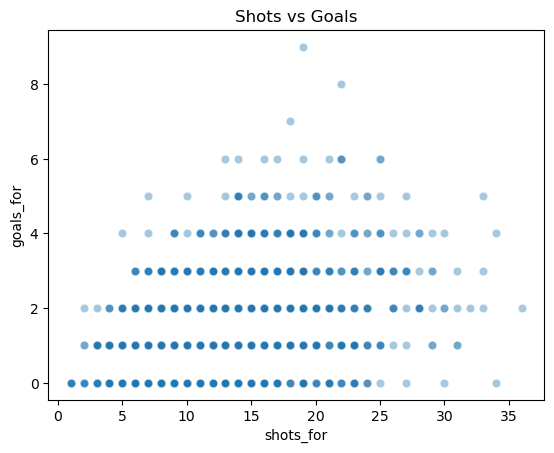

In [6]:
# Scatter: shots_for vs goals_for
sns.scatterplot(data=df, x="shots_for", y="goals_for", alpha=0.4)
plt.title("Shots vs Goals")
plt.show()


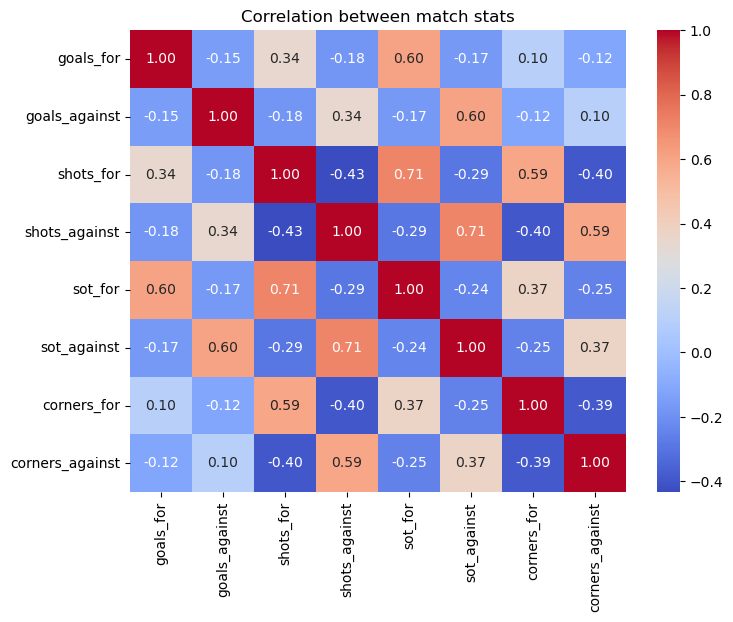

In [7]:
# Correlation heatmap for key stats
cols = ["goals_for", "goals_against", "shots_for", "shots_against",
        "sot_for", "sot_against", "corners_for", "corners_against"]
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between match stats")
plt.show()
